In [32]:
# basic imports, sklearn specific libraries are imported later on
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
# Removing warnings because who wants to see them
import warnings
warnings.filterwarnings("ignore")

# Display settings for easier DataFrame viewing
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

In [34]:
df = pd.read_csv('give_me_some_credit.csv')

In [35]:
# Shape
print("Shape:", df.shape)

Shape: (150000, 11)


In [36]:
# 5 rows how look
print("\nFirst 5 rows:")
df.head()


First 5 rows:


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.77,45,2,0.80,9120,13,0,6,0,2
1,0,0.96,40,0,0.12,2600,4,0,0,0,1
2,0,0.66,38,1,0.09,3042,2,1,0,0,0
3,0,0.23,30,0,0.04,3300,5,0,0,0,0
4,0,0.91,49,1,0.02,63588,7,0,1,0,0


In [37]:
# Data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         150000 non-null  str    
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    150000 non-null  str    
dtypes: float64(

In [38]:
# changing data types of these columns 
df['MonthlyIncome'] = pd.to_numeric(df['MonthlyIncome'], errors='coerce')
df['NumberOfDependents'] = pd.to_numeric(df['NumberOfDependents'], errors='coerce')

In [39]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.00,150000.00,150000.00,150000.00,150000.00,120269.00,150000.00,150000.00,150000.00,150000.00,146076.00
mean,0.07,6.05,52.30,0.42,353.01,6670.22,8.45,0.27,1.02,0.24,0.76
std,0.25,249.76,14.77,4.19,2037.82,14384.67,5.15,4.17,1.13,4.16,1.12
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.03,41.00,0.00,0.18,3400.00,5.00,0.00,0.00,0.00,0.00
50%,0.00,0.15,52.00,0.00,0.37,5400.00,8.00,0.00,1.00,0.00,0.00
75%,0.00,0.56,63.00,0.00,0.87,8249.00,11.00,0.00,2.00,0.00,1.00
max,1.00,50708.00,109.00,98.00,329664.00,3008750.00,58.00,98.00,54.00,98.00,20.00


### WHILE IMPORTING THE DATA, THE NULL VALUES WERE REPLACED BY "?" SO WE NEED TO FIX THAT, CHECK BELOW

In [40]:
# Checking FOR columns contain '?' values
print("Columns with '?' values:")
for col in df.columns:
    count = (df[col] == '?').sum()
    if count > 0:
        print(f"  {col}: {count} question marks")

Columns with '?' values:


In [41]:
# Replacing '?' with NaN in entire df
df.replace('?', np.nan, inplace=True)

# check again
print("Missing values after replacement:")
print(df.isnull().sum())

Missing values after replacement:
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64


In [42]:
# Duplicate rows
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 609


In [43]:
df.drop_duplicates(inplace=True) # removing duplicates here
df.reset_index(drop=True, inplace=True)

print(f"Shape after dropping duplicates: {df.shape}")

Shape after dropping duplicates: (149391, 11)


In [44]:
print("\nTarget distribution:")
print(df['SeriousDlqin2yrs'].value_counts())
print("\nTarget distribution (%):")
print(df['SeriousDlqin2yrs'].value_counts(normalize=True).round(3) * 100)


Target distribution:
SeriousDlqin2yrs
0    139382
1     10009
Name: count, dtype: int64

Target distribution (%):
SeriousDlqin2yrs
0   93.30
1    6.70
Name: proportion, dtype: float64


In [45]:
# renaming columns
df.rename(columns={
    'SeriousDlqin2yrs'                    : 'target',
    'RevolvingUtilizationOfUnsecuredLines' : 'revolving_util',
    'age'                                  : 'age',
    'NumberOfTime30-59DaysPastDueNotWorse' : 'late_30_59',
    'DebtRatio'                            : 'debt_ratio',
    'MonthlyIncome'                        : 'monthly_income',
    'NumberOfOpenCreditLinesAndLoans'      : 'open_credit_lines',
    'NumberOfTimes90DaysLate'              : 'late_90',
    'NumberRealEstateLoansOrLines'         : 'real_estate_loans',
    'NumberOfTime60-89DaysPastDueNotWorse' : 'late_60_89',
    'NumberOfDependents'                   : 'dependents' }, inplace=True)

print("Columns renamed successfully:")
print(df.columns.tolist())

Columns renamed successfully:
['target', 'revolving_util', 'age', 'late_30_59', 'debt_ratio', 'monthly_income', 'open_credit_lines', 'late_90', 'real_estate_loans', 'late_60_89', 'dependents']


### We have two columns which have null values in them, so we are using a fill and flag technique. We are creating flags for these two columns, which will show if that particular column had a value or not. 

In [46]:
df['monthly_income_missing'] = df['monthly_income'].isnull().astype(int)
df['dependents_missing'] = df['dependents'].isnull().astype(int)

print("Missing flags created:")
print(df['monthly_income_missing'].value_counts())
print()
print(df['dependents_missing'].value_counts())

Missing flags created:
monthly_income_missing
0    120170
1     29221
Name: count, dtype: int64

dependents_missing
0    145563
1      3828
Name: count, dtype: int64


In [47]:
# Finding both the mean and median, and then checking the distribution of dependents 
# to determine which statistic to use 

print("Monthly Income:")
print(f"  Mean   : {df['monthly_income'].mean():.2f}")
print(f"  Median : {df['monthly_income'].median():.2f}")

print("\nDependents:")
print(f"  Mean   : {df['dependents'].mean():.2f}")
print(f"  Median : {df['dependents'].median():.2f}")

# Check distribution of dependents
print("\nDependents value counts:")
print(df['dependents'].value_counts().sort_index())

Monthly Income:
  Mean   : 6675.10
  Median : 5400.00

Dependents:
  Mean   : 0.76
  Median : 0.00

Dependents value counts:
dependents
0.00     86392
1.00     26314
2.00     19521
3.00      9483
4.00      2862
5.00       746
6.00       158
7.00        51
8.00        24
9.00         5
10.00        5
13.00        1
20.00        1
Name: count, dtype: int64


In [48]:
# IMPUTING THE VALUES WITH JUSTIFICATIONS

# Monthly income is right-skewed (mean: 6670 vs median: 5400),
# so median is a better representative of the typical borrower.

# also

# Dependents is a count variable where 60% of borrowers report zero;
# rounded mean (1) is used instead of median (0) to avoid assigning
# "no dependents" to all missing cases by default.

df['monthly_income'].fillna(df['monthly_income'].median(), inplace=True)

dependents_fill = round(df['dependents'].mean())
print(f"Filling dependents with: {dependents_fill}")
df['dependents'].fillna(dependents_fill, inplace=True)

# Verify no nulls remain
print("\nMissing values after imputation:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Filling dependents with: 1

Missing values after imputation:
target                        0
revolving_util                0
age                           0
late_30_59                    0
debt_ratio                    0
monthly_income            29221
open_credit_lines             0
late_90                       0
real_estate_loans             0
late_60_89                    0
dependents                 3828
monthly_income_missing        0
dependents_missing            0
dtype: int64

Total missing: 33049


In [49]:
df['monthly_income']

0         9120.00
1         2600.00
2         3042.00
3         3300.00
4        63588.00
           ...   
149386    2100.00
149387    5584.00
149388        NaN
149389    5716.00
149390    8158.00
Name: monthly_income, Length: 149391, dtype: float64

In [50]:
# `fillna(..., inplace=True)` on a column selected from the DataFrame did not  update the original df.
# So, first changing to numeric and then assigning the filled series back to the column.
df['monthly_income'] = pd.to_numeric(df['monthly_income'], errors='coerce')
df['dependents'] = pd.to_numeric(df['dependents'], errors='coerce')

In [51]:
print(df['monthly_income'].isna().sum())
print(df['dependents'].isna().sum())

29221
3828


In [52]:
df['monthly_income'] = df['monthly_income'].fillna(df['monthly_income'].median())
df['dependents'] = df['dependents'].fillna(round(df['dependents'].mean()))

In [53]:
print(df['monthly_income'].isna().sum())
print(df['dependents'].isna().sum())

0
0


In [54]:
# Verify no nulls remain again
print("\nMissing values after imputation:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")


Missing values after imputation:
target                    0
revolving_util            0
age                       0
late_30_59                0
debt_ratio                0
monthly_income            0
open_credit_lines         0
late_90                   0
real_estate_loans         0
late_60_89                0
dependents                0
monthly_income_missing    0
dependents_missing        0
dtype: int64

Total missing: 0


In [55]:
df.head()

,target,revolving_util,age,late_30_59,debt_ratio,monthly_income,open_credit_lines,late_90,real_estate_loans,late_60_89,dependents,monthly_income_missing,dependents_missing
0,1,0.77,45,2,0.80,9120.00,13,0,6,0,2.00,0,0
1,0,0.96,40,0,0.12,2600.00,4,0,0,0,1.00,0,0
2,0,0.66,38,1,0.09,3042.00,2,1,0,0,0.00,0,0
3,0,0.23,30,0,0.04,3300.00,5,0,0,0,0.00,0,0
4,0,0.91,49,1,0.02,63588.00,7,0,1,0,0.00,0,0


In [56]:
# checking for outliers

cols_to_check = ['revolving_util', 'debt_ratio', 'age', 'late_30_59', 'late_60_89', 'late_90']

for col in cols_to_check:
    print(f"{col}:")
    print(f"  Max: {df[col].max()}")
    print(f"  99th percentile: {df[col].quantile(0.99):.2f}")
    print()

revolving_util:
  Max: 50708.0
  99th percentile: 1.09

debt_ratio:
  Max: 329664.0
  99th percentile: 4985.10

age:
  Max: 109
  99th percentile: 87.00

late_30_59:
  Max: 98
  99th percentile: 4.00

late_60_89:
  Max: 98
  99th percentile: 2.00

late_90:
  Max: 98
  99th percentile: 3.00



In [57]:
df['late_90'].value_counts().sort_values(ascending=False)

late_90
0     141108
1       5232
2       1555
3        667
4        291
98       220
5        131
6         80
7         38
8         21
9         19
10         8
96         5
11         5
13         4
15         2
14         2
12         2
17         1
Name: count, dtype: int64

In [61]:
# ----- OUTLIER CAPPING -----

# Check for zero ages first (Fixed the extra quote here)
print(f"Zero age count: {(df['age'] == 0).sum()}")

# revolving_util is a utilization ratio where 1.0 means credit limit is fully used.
# Max of 50,708 is clearly a data entry error. Capping at 1.5 allows slight
# over-limit cases while eliminating impossible values.
df['revolving_util'] = df['revolving_util'].clip(upper=1.5)

# debt_ratio extremes up to 329,664 are not economically meaningful.
# Capping at the 99th percentile retains genuine high-debt cases
# while removing values that are almost certainly recording errors.
debt_ratio_cap = df['debt_ratio'].quantile(0.99)
df['debt_ratio'] = df['debt_ratio'].clip(upper=debt_ratio_cap)

# Age of 0 is impossible for a loan borrower; these are missing or corrupt entries
# disguised as zeros. Median is used because age is slightly skewed,
# and median better represents the typical borrower than mean would.
# Capping at 87 removes the extreme upper end while keeping realistic senior borrowers.
df['age'] = df['age'].clip(upper=87)
df['age'] = df['age'].replace(0, df['age'].median())

# Max of 98 across all three late payment columns is a known sentinel value
# in this dataset, used to represent unknown or erroneous entries, not an
# actual count. In a 2 year window, being late more than 10 times is already
# extreme, so capping at 10 removes sentinel errors while keeping genuine outliers.
df['late_30_59'] = df['late_30_59'].clip(upper=10)
df['late_60_89'] = df['late_60_89'].clip(upper=10)
df['late_90']    = df['late_90'].clip(upper=10)

# Verify
print("\nAfter capping:")
for col in ['revolving_util', 'debt_ratio', 'age',
            'late_30_59', 'late_60_89', 'late_90']:
    print(f"  {col} max: {df[col].max()}")

Zero age count: 1

After capping:
  revolving_util max: 1.5
  debt_ratio max: 4985.100000000006
  age max: 87
  late_30_59 max: 10
  late_60_89 max: 10
  late_90 max: 10


## FEATURE ENGINEERING

In [67]:
# Create 5 new features to capture overall delinquency, income per dependent, late payment history, delinquency severity, and high credit utilization

df['total_times_late'] = (
    df['late_30_59'] +
    df['late_60_89'] +
    df['late_90']
)  # Combines all late payments into one overall delinquency count

df['income_per_dependent'] = (
    df['monthly_income'] /
    np.where(df['dependents'] == 0, 1, df['dependents'])
)  # Shows how much monthly income is available relative to the number of dependents

df['ever_late'] = (
    df['total_times_late'] > 0
).astype(int)  # Simple yes/no flag showing whether the borrower has ever been late

df['delinquency_severity'] = (
    df['late_30_59'] * 1 +
    df['late_60_89'] * 2 +
    df['late_90'] * 3
)  # Gives more weight to serious late payments like 90+ days

df['high_utilization'] = (
    df['revolving_util'] > 1
).astype(int)  # Flags borrowers using more than 100% of their available revolving credit

# Check the new features
print("New features added:")
print(
    df[
        [
            'total_times_late',
            'income_per_dependent',
            'ever_late',
            'delinquency_severity',
            'high_utilization'
        ]
    ].describe()
)

print(f"\nNew shape: {df.shape}")

New features added:
       total_times_late  income_per_dependent  ever_late  \
count         149391.00             149391.00  149391.00   
mean               0.45               5426.47       0.20   
std                1.59               9357.87       0.40   
min                0.00                  0.00       0.00   
25%                0.00               2840.00       0.00   
50%                0.00               5112.00       0.00   
75%                0.00               6000.00       0.00   
max               30.00            1794060.00       1.00   

       delinquency_severity  high_utilization  
count             149391.00         149391.00  
mean                   0.74              0.02  
std                    3.09              0.15  
min                    0.00              0.00  
25%                    0.00              0.00  
50%                    0.00              0.00  
75%                    0.00              0.00  
max                   60.00              1.00  

New sh

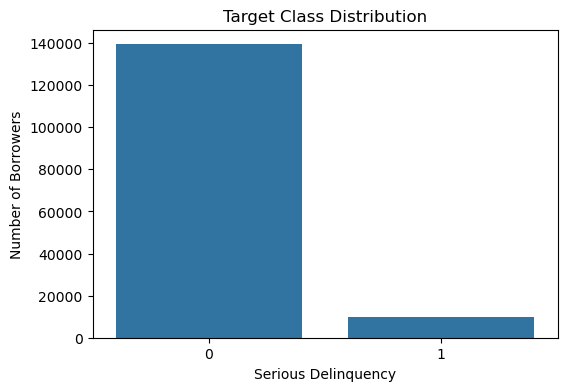

target
0   93.30
1    6.70
Name: proportion, dtype: float64


In [71]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='target')

plt.title('Target Class Distribution')
plt.xlabel('Serious Delinquency')
plt.ylabel('Number of Borrowers')
plt.show()

print(
    df['target']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

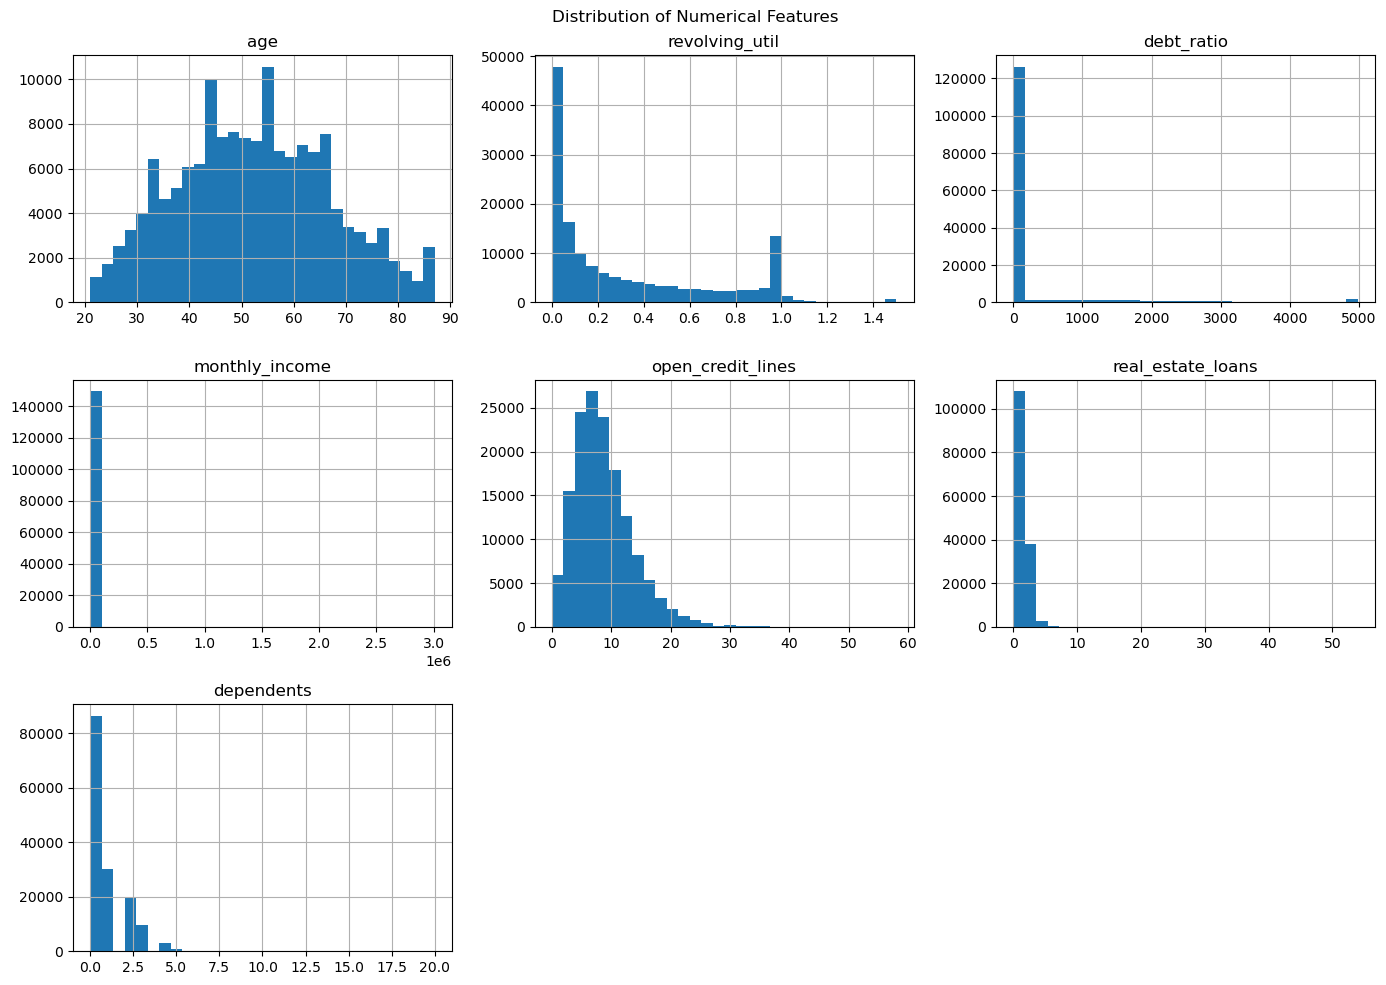

In [72]:
cols = [
    'age',
    'revolving_util',
    'debt_ratio',
    'monthly_income',
    'open_credit_lines',
    'real_estate_loans',
    'dependents'
]

df[cols].hist(figsize=(14, 10), bins=30)

plt.suptitle('Distribution of Numerical Features')
plt.tight_layout()
plt.show()

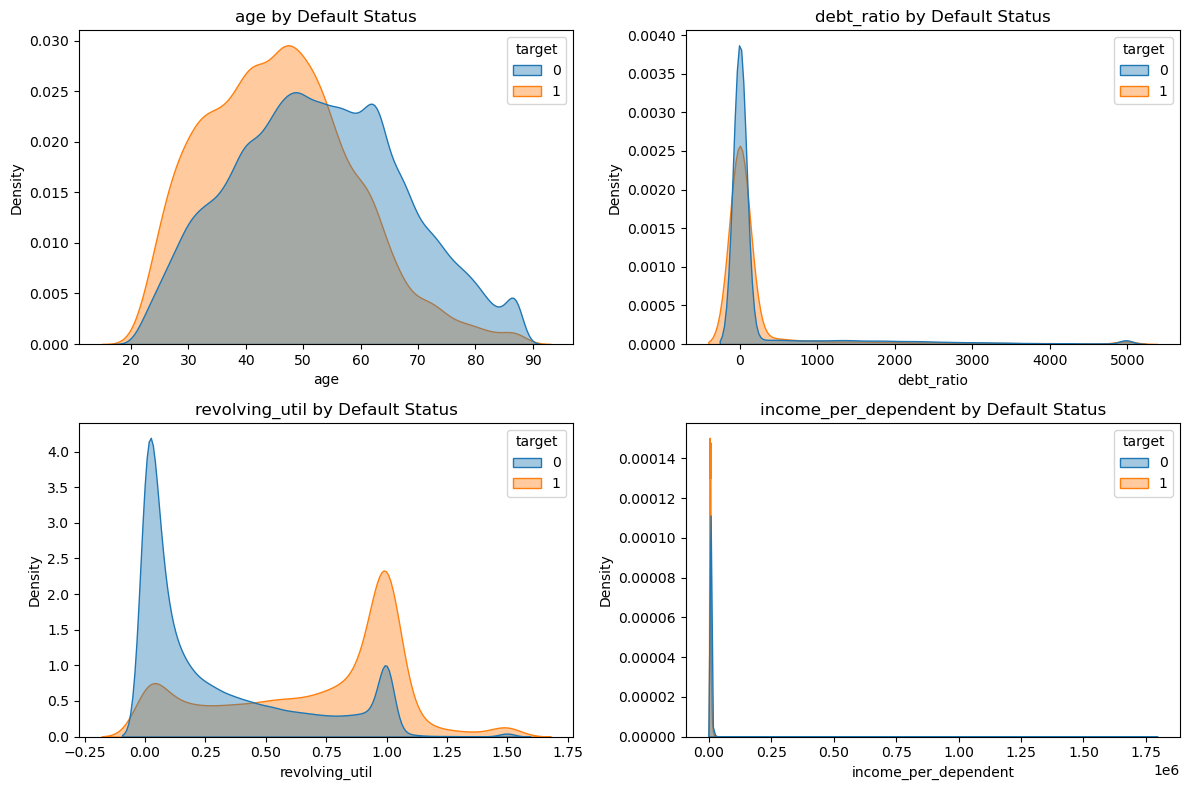

In [79]:
features_to_plot = ['age', 'debt_ratio', 'revolving_util', 'income_per_dependent']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    sns.kdeplot(data=df, x=col, hue='target', fill=True,
                common_norm=False, alpha=0.4, ax=axes[i])
    axes[i].set_title(f'{col} by Default Status')

plt.tight_layout()
plt.show()

In [80]:
# Apply log transformation to heavily right-skewed columns to reduce 
# the effect of extreme values and make the distributions easier to work with

df['debt_ratio_log'] = np.log1p(df['debt_ratio'])  # Compresses the long right tail while keeping 0 values valid

df['monthly_income_log'] = np.log1p(df['monthly_income'])  
# Compresses extreme income values and makes the overall spread easier to see

# Verify the transformation worked as expected
print(df[['debt_ratio', 'debt_ratio_log', 'monthly_income', 'monthly_income_log']].describe())

       debt_ratio  debt_ratio_log  monthly_income  monthly_income_log
count   149391.00       149391.00       149391.00           149391.00
mean       317.89            1.53         6425.69                8.45
std        908.90            2.62        12915.67                1.19
min          0.00            0.00            0.00                0.00
25%          0.18            0.16         3900.00                8.27
50%          0.37            0.31         5400.00                8.59
75%          0.88            0.63         7400.00                8.91
max       4985.10            8.51      3008750.00               14.92


In [81]:
# now we run the plots again

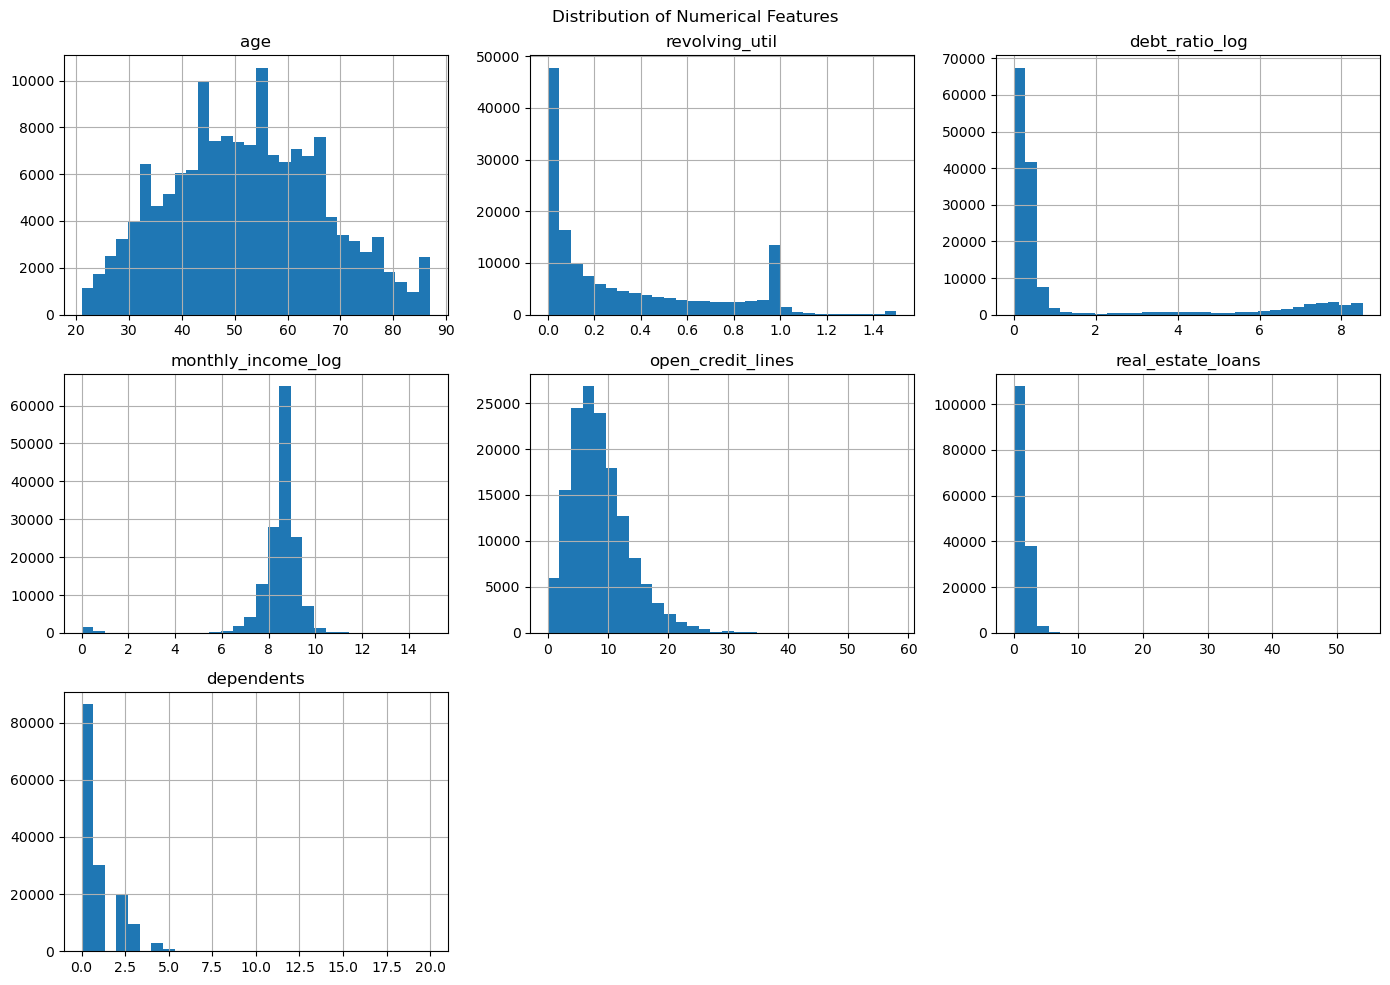

In [83]:
cols = [
    'age',
    'revolving_util',
    'debt_ratio_log',
    'monthly_income_log',
    'open_credit_lines',
    'real_estate_loans',
    'dependents'
]

df[cols].hist(figsize=(14, 10), bins=30)

plt.suptitle('Distribution of Numerical Features')
plt.tight_layout()
plt.show()

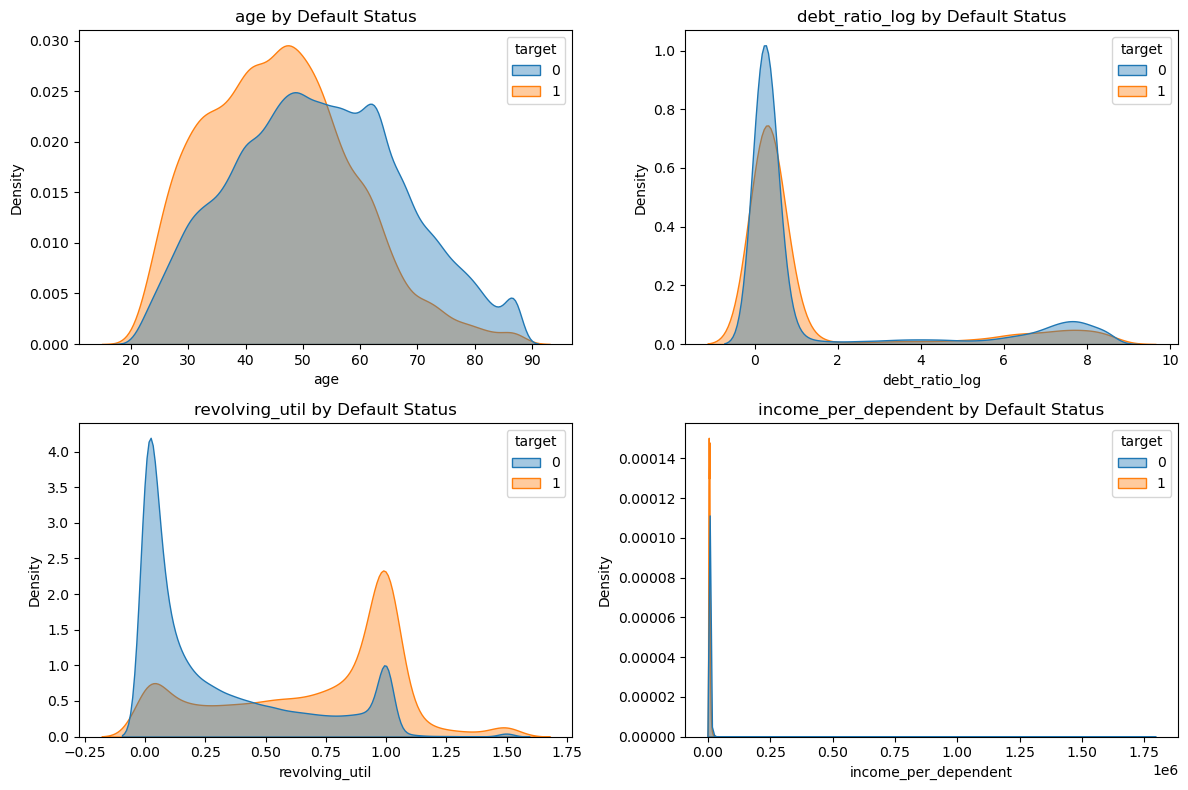

In [84]:
features_to_plot = ['age', 'debt_ratio_log', 'revolving_util', 'income_per_dependent']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    sns.kdeplot(data=df, x=col, hue='target', fill=True,
                common_norm=False, alpha=0.4, ax=axes[i])
    axes[i].set_title(f'{col} by Default Status')

plt.tight_layout()
plt.show()

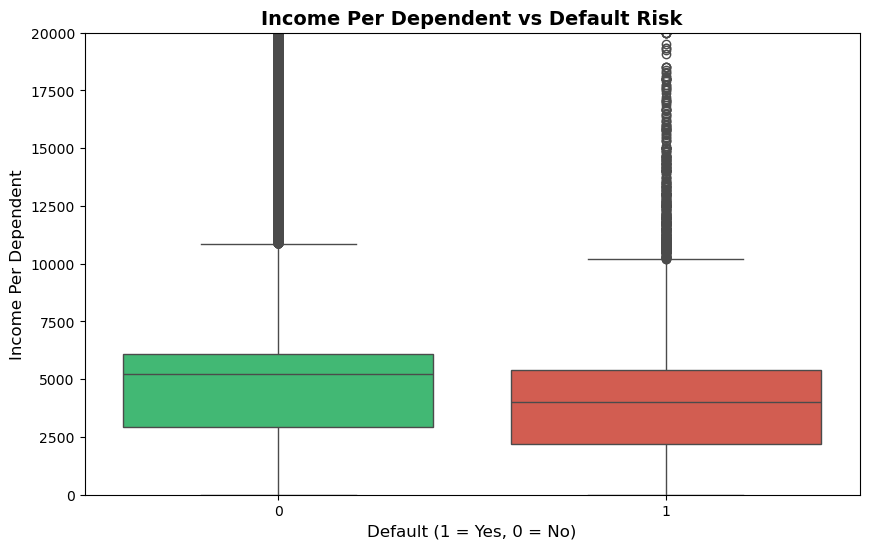

In [77]:

plt.figure(figsize=(10, 6))
# Boxplot showing how 'income_per_dependent' differs between defaulters and non-defaulters
# We cap the y-axis at 20000 to prevent extreme outliers from squishing the plot
sns.boxplot(x='target', y='income_per_dependent', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title('Income Per Dependent vs Default Risk', fontsize=14, fontweight='bold')
plt.xlabel('Default (1 = Yes, 0 = No)', fontsize=12)
plt.ylabel('Income Per Dependent', fontsize=12)
plt.ylim(0, 20000) # Cap y-axis for readability
plt.show()

In [85]:
# Interpretation: Income Per Dependent vs Default Risk

# Defaulters have a lower median income per dependent (~4,000) than non-defaulters (~5,200)
# The IQR for defaulters is also mostly below non-defaulters
# This suggests that lower income per household member may be linked with higher default risk

# The separation is moderate, not very strong
# The two groups still overlap a lot, so this feature alone cannot clearly separate defaulters from non-defaulters
# Useful as a supporting feature for the model, not a standalone predictor

# The dense points above the whiskers are due to the long right tail
# Y-axis was capped at 20,000 only for readability, the original outlier values are still present

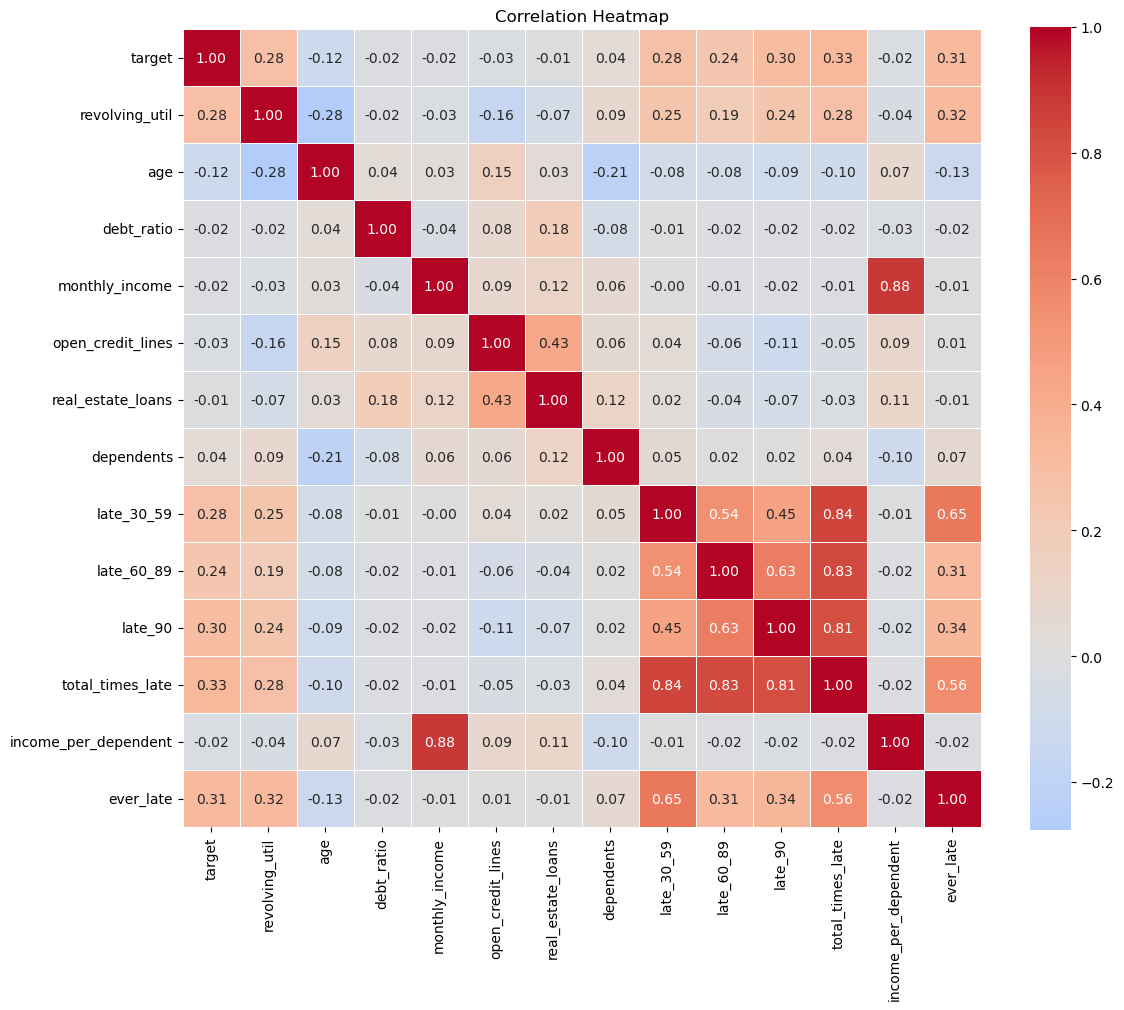

In [78]:
# Deliberately includes the engineered features alongside their
# source columns, so multicollinearity (e.g. total_times_late
# with the three late_* columns it was built from) is visible
# and can be addressed knowingly, not discovered later by accident.
numeric_cols = ['target', 'revolving_util', 'age', 'debt_ratio', 'monthly_income',
                 'open_credit_lines', 'real_estate_loans', 'dependents',
                 'late_30_59', 'late_60_89', 'late_90',
                 'total_times_late', 'income_per_dependent', 'ever_late']

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [ ]:
# interpretation of the Correlation Heatmap 

# income_per_dependent and monthly_income are highly correlated (0.88),
# as expected since one is derived from the other. Same logic applies
# to total_times_late and its three source columns (late_30_59,
# late_60_89, late_90), correlations of 0.81-0.84. Tree-based models
# (Random Forest, Gradient Boosting) are robust to this kind of
# multicollinearity, since they split on one feature at a time rather
# than estimating coefficients across all features simultaneously.

# The strongest predictors of target are total_times_late (0.33),
# ever_late (0.31), late_90 (0.30), revolving_util (0.28), and
# late_30_59 (0.28). Notably, two of the three engineered features
# rank among the top predictors, confirming the feature engineering
# added real signal rather than redundancy.

# debt_ratio and income_per_dependent show near-zero linear correlation
# with target, but this does not rule them out as useful predictors.
# Correlation only captures linear relationships; tree-based models
# can still exploit non-linear patterns in these features.

## MODEL BUILDING

In [91]:
# imports
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)


# making features and target

# Use raw debt_ratio and monthly_income since tree models split on thresholds
# Log versions are kept only for visualization
feature_cols = ['revolving_util', 'age', 'debt_ratio', 'monthly_income',
                 'open_credit_lines', 'real_estate_loans', 'dependents',
                 'late_30_59', 'late_60_89', 'late_90',
                 'total_times_late', 'income_per_dependent', 'ever_late']

X = df[feature_cols]
y = df['target']


# split

# using stratify here to keep the default rate similar in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train default rate: {y_train.mean():.4f}")
print(f"Test default rate: {y_test.mean():.4f}")

Train shape: (119512, 13), Test shape: (29879, 13)
Train default rate: 0.0670
Test default rate: 0.0670


In [92]:
# This function exists so we don't have to write the same block of
# metric calculations and print statements three separate times,
# once for each model. Call it once per model instead.
def evaluate_model(name, model, X_test, y_test):
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    metrics = {
        'model': name,
        'accuracy': accuracy_score(y_test, preds),
        'precision': precision_score(y_test, preds),
        'recall': recall_score(y_test, preds),
        'f1': f1_score(y_test, preds),
        'roc_auc': roc_auc_score(y_test, probs)
    }

    print(f"......{name}.... ")
    print(f"Accuracy : {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall   : {metrics['recall']:.4f}")
    print(f"F1 Score : {metrics['f1']:.4f}")
    print(f"ROC-AUC  : {metrics['roc_auc']:.4f}")

    # ConfusionMatrixDisplay for a visual breakdown of correct vs.
    # incorrect predictions by class.
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Serious Delinquency', 'Serious Delinquency'])
    disp.plot(cmap='Blues')
    plt.title(f'{name} - Confusion Matrix')
    plt.show()
    print(classification_report(y_test, preds))

    return metrics

results = []

......Decision Tree.... 
Accuracy : 0.7793
Precision: 0.2017
Recall   : 0.7752
F1 Score : 0.3201
ROC-AUC  : 0.8520


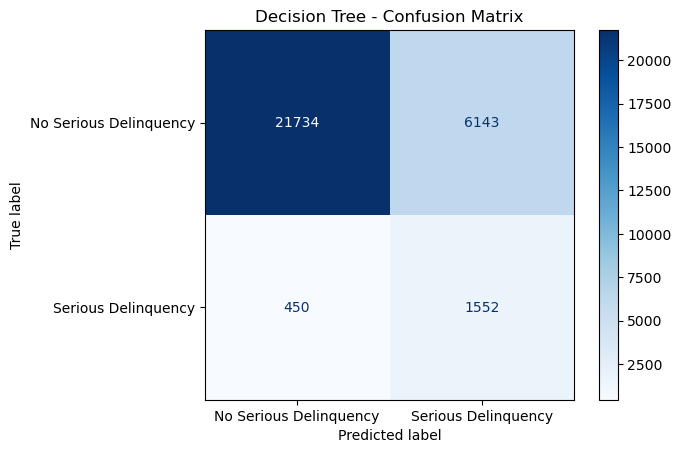

              precision    recall  f1-score   support

           0       0.98      0.78      0.87     27877
           1       0.20      0.78      0.32      2002

    accuracy                           0.78     29879
   macro avg       0.59      0.78      0.59     29879
weighted avg       0.93      0.78      0.83     29879



In [93]:
# MODEL 1

# the baseline using decision tree

# class_weight='balanced' tells the tree to weight the minority class
# (defaulters) more heavily during training, so it doesn't just learn
# to always predict "no default" to rack up easy accuracy.

dt_model = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=50,   # prevents leaves from fitting to tiny, noisy subsets
    class_weight='balanced',
    random_state=42
)

dt_model.fit(X_train, y_train)

results.append(evaluate_model('Decision Tree', dt_model, X_test, y_test))

Best params: {'ccp_alpha': 0.0, 'max_depth': 6, 'min_samples_leaf': 100}
Best CV ROC-AUC: 0.8529361855330742
......Decision Tree (tuned).... 
Accuracy : 0.7793
Precision: 0.2019
Recall   : 0.7772
F1 Score : 0.3206
ROC-AUC  : 0.8538


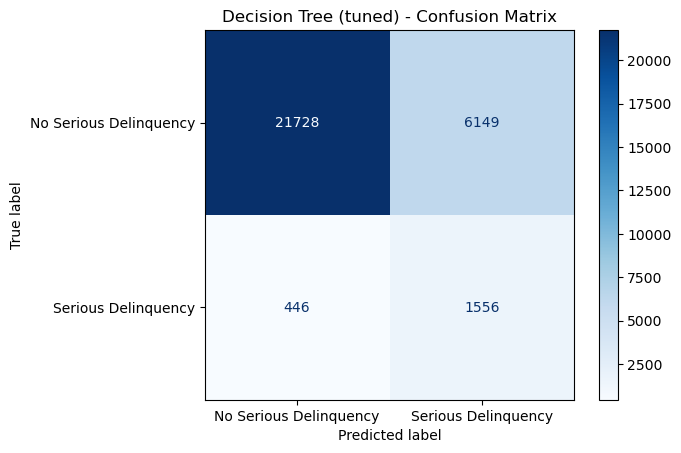

              precision    recall  f1-score   support

           0       0.98      0.78      0.87     27877
           1       0.20      0.78      0.32      2002

    accuracy                           0.78     29879
   macro avg       0.59      0.78      0.59     29879
weighted avg       0.93      0.78      0.83     29879



In [94]:
# TUNING THE DECISION TREE USING GridSearchCV

dt_param_grid = {
    'max_depth': [4, 6, 8, 10],
    'min_samples_leaf': [20, 50, 100],
    'ccp_alpha': [0.0, 0.001, 0.005]
}

dt_grid_search = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid=dt_param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)
dt_grid_search.fit(X_train, y_train)

print("Best params:", dt_grid_search.best_params_)
print("Best CV ROC-AUC:", dt_grid_search.best_score_)

dt_model = dt_grid_search.best_estimator_
results.append(evaluate_model('Decision Tree (tuned)', dt_model, X_test, y_test))

......Random Forest.... 
Accuracy : 0.8292
Precision: 0.2411
Recall   : 0.7213
F1 Score : 0.3614
ROC-AUC  : 0.8597


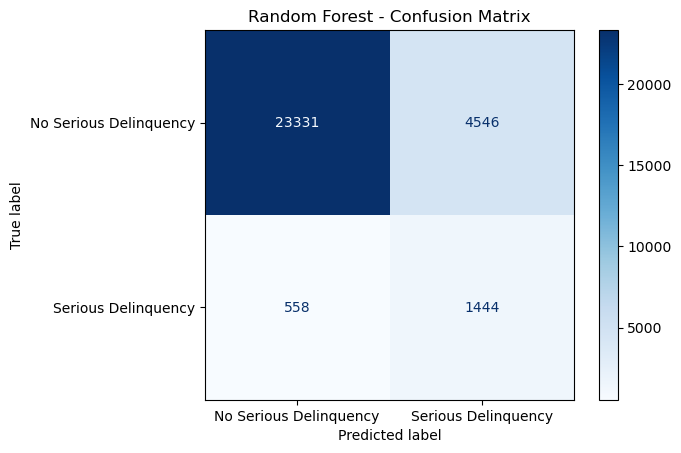

              precision    recall  f1-score   support

           0       0.98      0.84      0.90     27877
           1       0.24      0.72      0.36      2002

    accuracy                           0.83     29879
   macro avg       0.61      0.78      0.63     29879
weighted avg       0.93      0.83      0.87     29879



In [96]:
#  RANDOM FOREST 

# Random Forest builds many decision trees on bootstrapped samples of
# the data, each considering a random subset of features at each split,
# then averages their predictions. This reduces the overfitting a
# single deep tree is prone to.
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

results.append(evaluate_model('Random Forest', rf_model, X_test, y_test))

Best params: {'n_estimators': 300, 'min_samples_leaf': 100, 'max_features': 'sqrt', 'max_depth': 12}
Best CV ROC-AUC: 0.8640678035778139
......Random Forest (tuned).... 
Accuracy : 0.8119
Precision: 0.2284
Recall   : 0.7602
F1 Score : 0.3513
ROC-AUC  : 0.8633


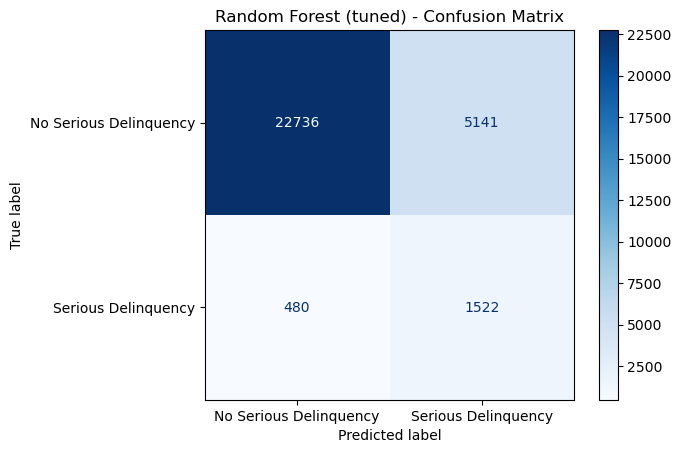

              precision    recall  f1-score   support

           0       0.98      0.82      0.89     27877
           1       0.23      0.76      0.35      2002

    accuracy                           0.81     29879
   macro avg       0.60      0.79      0.62     29879
weighted avg       0.93      0.81      0.85     29879



In [95]:
# TUNING RANDOM FOREST USING RANDOMIZEDSEARCHCV 

# The Decision Tree grid above (36 combinations) is small enough for
# GridSearchCV to check exhaustively. Random Forest's search space is
# larger, and each fit trains n_estimators trees instead of one, so an
# exhaustive grid here would be far more expensive for little extra
# gain. RandomizedSearchCV samples a fixed number of combinations
# instead, giving a strong result without the full computational cost.

rf_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [6, 8, 10, 12],
    'min_samples_leaf': [20, 50, 100],
    'max_features': ['sqrt', 'log2']
}

rf_random_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=15,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)
rf_random_search.fit(X_train, y_train)

print("Best params:", rf_random_search.best_params_)
print("Best CV ROC-AUC:", rf_random_search.best_score_)

rf_model = rf_random_search.best_estimator_
results.append(evaluate_model('Random Forest (tuned)', rf_model, X_test, y_test))

Best params: {'subsample': 0.8, 'n_estimators': 150, 'max_depth': 5, 'learning_rate': 0.05}
......Gradient Boosting (tuned).... 
Accuracy : 0.9361
Precision: 0.5673
Recall   : 0.1958
F1 Score : 0.2911
ROC-AUC  : 0.8648


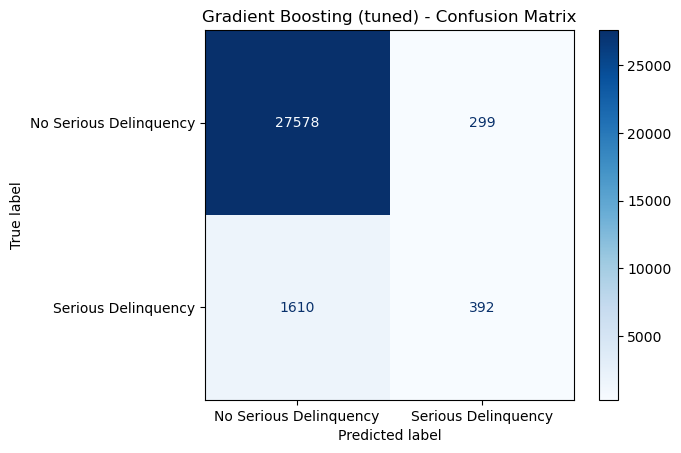

              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27877
           1       0.57      0.20      0.29      2002

    accuracy                           0.94     29879
   macro avg       0.76      0.59      0.63     29879
weighted avg       0.92      0.94      0.92     29879



In [97]:
# GRADIENT BOOSTING directly with hyperparameter tuning

# RandomizedSearchCV is used instead of GridSearchCV because with ~120K training rows, an exhaustive grid search across multiple
# parameters would be very slow. RandomizedSearchCV samples a fixed number of combinations instead of trying every single one, giving
# a good result much faster.
param_dist = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 0.9]
}

gb_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=10,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1
)
gb_search.fit(X_train, y_train)

print("Best params:", gb_search.best_params_)
gb_model = gb_search.best_estimator_

results.append(evaluate_model('Gradient Boosting (tuned)', gb_model, X_test, y_test))

In [99]:
# ----- COMPARISON TABLE -----
comparison_df = pd.DataFrame(results).set_index('model')
print(comparison_df)

                           accuracy  precision  recall   f1  roc_auc
model                                                               
Decision Tree                  0.78       0.20    0.78 0.32     0.85
Decision Tree (tuned)          0.78       0.20    0.78 0.32     0.85
Random Forest (tuned)          0.81       0.23    0.76 0.35     0.86
Random Forest                  0.83       0.24    0.72 0.36     0.86
Gradient Boosting (tuned)      0.94       0.57    0.20 0.29     0.86


In [101]:
## Model comparison summary

# Accuracy is not the main metric here because the target is highly imbalanced  
# Decision Tree gives the highest recall, while Random Forest gives a better balance between precision and recall  
# Gradient Boosting has slightly better AUC, but its recall is much lower because class imbalance was not handled  
# For this lending use case, Random Forest gives a reasonable balance between catching delinquents and reducing false positives  
# The detailed explanation and model comparison are available in the GitHub repository

## FEATURE IMPORTANCES

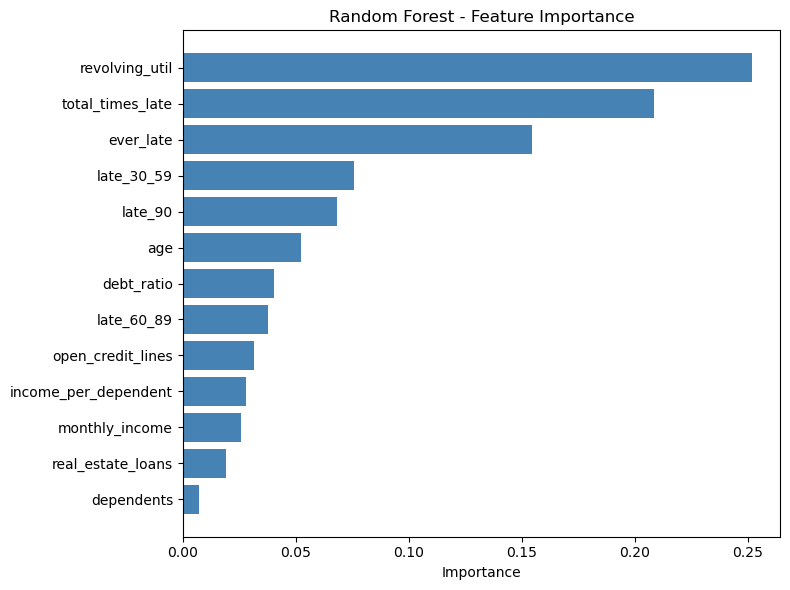

revolving_util         0.25
total_times_late       0.21
ever_late              0.15
late_30_59             0.08
late_90                0.07
age                    0.05
debt_ratio             0.04
late_60_89             0.04
open_credit_lines      0.03
income_per_dependent   0.03
monthly_income         0.03
real_estate_loans      0.02
dependents             0.01
dtype: float64


In [102]:
# FEATURE IMPORTANCE - Random Forest

rf_importances = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(rf_importances.index, rf_importances.values, color='steelblue')
plt.gca().invert_yaxis()  # highest importance on top
plt.title('Random Forest - Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(rf_importances)

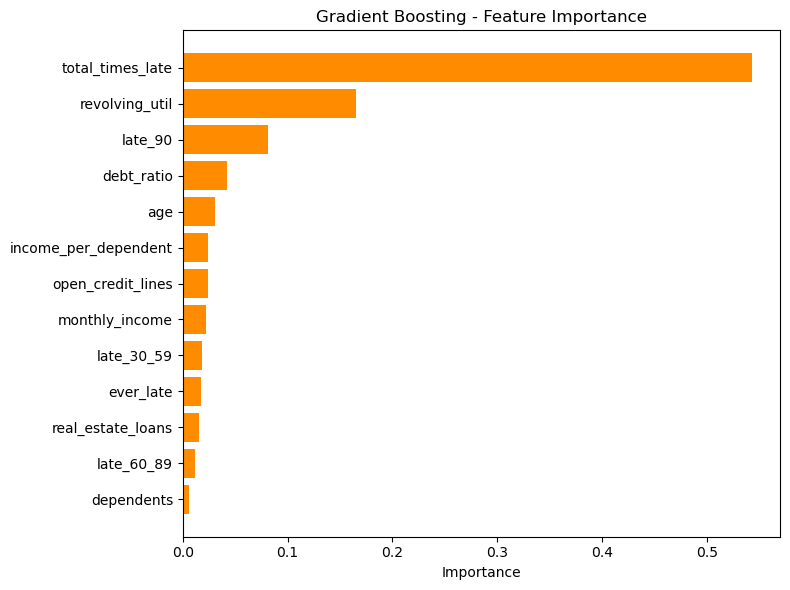

total_times_late       0.54
revolving_util         0.17
late_90                0.08
debt_ratio             0.04
age                    0.03
income_per_dependent   0.02
open_credit_lines      0.02
monthly_income         0.02
late_30_59             0.02
ever_late              0.02
real_estate_loans      0.02
late_60_89             0.01
dependents             0.01
dtype: float64


In [103]:
# FEATURE IMPORTANCE - Gradient Boosting

gb_importances = pd.Series(
    gb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(gb_importances.index, gb_importances.values, color='darkorange')
plt.gca().invert_yaxis()
plt.title('Gradient Boosting - Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(gb_importances)

### Feature importance summary

Both Random Forest and Gradient Boosting agree that `revolving_util` and payment history are the strongest risk signals  
`total_times_late` is especially important and ranks in the top 2 for both models, showing that the engineered feature added useful signal  
The models differ in how they distribute importance, especially for `ever_late`, because of their different ensemble mechanics and feature redundancy  
`income_per_dependent` added limited signal, while `dependents` and `real_estate_loans` were among the weaker features  
These are Gini-based importances, so permutation importance would be a better follow-up for a more reliable comparison

# CONCLUSION

This project compares Decision Tree, Random Forest, and Gradient Boosting models for predicting serious delinquency using the "Give Me Some Credit" dataset

The target is highly imbalanced (~6.7% delinquent), so accuracy alone is misleading  
Recall was treated as the main metric since missing an actual delinquent borrower can be more costly than flagging a safe borrower

Decision Tree and Random Forest used `class_weight='balanced'`, while Gradient Boosting did not  
This explains much of the difference in recall — the weighted models reached around 72-78% recall, while Gradient Boosting was around 20%  
All three models had similar ROC-AUC (~0.85-0.86), so their underlying risk ranking was fairly similar

Random Forest was selected as the strongest overall model, giving a better balance between precision and recall than the Decision Tree while maintaining similar AUC

Feature importance was also consistent across the models  
`revolving_util`, `total_times_late`, and previous late payments were the strongest signals  
`total_times_late` ranked in the top 2 for both models, showing that the feature engineering added useful signal  
`income_per_dependent` had much less impact and did not clearly outperform raw `monthly_income`

### If the CEO asks: "Which model would you use?"

"I'd go with Random Forest. I compared all three models mainly on how well they catch delinquent borrowers, not just accuracy, because missing a risky borrower is more costly than a false alarm. Random Forest gave me a good balance between recall and precision, while its AUC was also similar to Gradient Boosting. Gradient Boosting looked better on accuracy, but it wasn't handling the class imbalance the same way. So for this version, I'd use Random Forest